# 3장 실습 — 시연 수와 다양성의 스케일링

2장이 **어떤 경로로** 모을지를 정했다. 이 노트북은 **얼마나** 모을지를 정한다.

질문은 둘이다.

1. 시연 수를 늘리면 실패율이 거듭제곱으로 줄어드는가. 줄어든다면 그 지수는 얼마이고, 명목과 배포에서 같은가
2. 같은 시연 수라면 **새 배치를 보여 주는 것**과 **같은 배치를 되풀이하는 것** 가운데 무엇이 나은가

두 번째 질문이 Lin 외(ICLR 2025)가 실기에서 던진 질문이다. 이 노트북은 그 질문을 분류 셀에서 다시 던지고, 답이 **잡음 주입 여부**에 따라 뒤집힌다는 것을 보인다.

2장이 남긴 `data/collect.json` 을 읽고, 끝에서 시연 수를 적어 넣는다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="sorting_cell">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="part" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
SEP, BX = .10, .28                      # 적재함 위치 (m)
MODEL = mujoco.MjModel.from_xml_string(XML)


def bin_xy(k):
    """A형(k=0)은 왼쪽, B형(k=1)은 오른쪽 적재함이다"""
    return np.array([BX, (1 - 2 * k) * SEP])


class Cell:
    """평면 분류 셀 — 부품을 종류에 맞는 칸으로 민다"""

    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.k = np.zeros(n, int)
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        self.k[i] = self.rng.integers(0, 2)
        jit = self.rng.uniform(-.03, .03, 2)
        self.g[i] = bin_xy(self.k[i]) + jit
        b = np.array([bx, by])
        v = self.g[i] - b
        d.qpos[7:9] = b - v / np.linalg.norm(v) * .09
        mujoco.mj_forward(self.m, d)
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.zeros((self.n, 10), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = (self.g[i] - b) * 10.
            o[i, 2:4] = d.qvel[0:2] * 10.
            o[i, 4:6] = (b - d.qpos[7:9]) * 10.
            o[i, 6:8] = d.qvel[6:8] * 10.
            o[i, 8 + self.k[i]] = 1.          # 종류 표시
        return o

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            hit = db < GOAL_R
            if hit or self.t[i] >= EP:
                dn[i] = 1.
                other = bin_xy(1 - self.k[i])
                wrong = np.linalg.norm(d.qpos[0:2] - other) < .06
                sc.append((int(hit), int(wrong), int(self.t[i]),
                           int(self.k[i])))
                self.reset(i)
        return r, dn, sc

In [4]:
class Pert(Cell):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("적재함 A", np.round(bin_xy(0), 2))
print("적재함 B", np.round(bin_xy(1), 2))
print("평가 조건:", ", ".join(COND))

적재함 A [0.28 0.1 ]
적재함 B [ 0.28 -0.1 ]
평가 조건: 명목, 배포


In [5]:
class AC(nn.Module):
    def __init__(self, din=10):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

In [6]:
import os
import csv
import json


def unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > 1e-9, v / np.maximum(n, 1e-9), 0.)


def servo(env):
    """1장의 대본 전문가 — 부품 뒤로 돌아가 적재함 쪽으로 민다"""
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    dv = unit(env.g - b)
    behind = b - dv * .045
    e = behind - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)


COLS = ["cond", "version", "seed", "kind", "success", "wrong",
        "steps"]


def rollout(actfn, cond, seed=999, n=150, reps=3, tag=0, ver="v0"):
    """1장의 로그 스키마 그대로 판마다 한 줄을 남긴다"""
    env = Pert(n, seed, **COND[cond])
    rows = []
    for t in range(EP * reps):
        _, dn, sc = env.step(actfn(env))
        for hit, wrong, steps, k in sc:
            rows.append((cond, ver, tag, "AB"[k], hit, wrong,
                         steps))
    return rows


def rate(rows):
    return sum(r[4] for r in rows) / len(rows)


def bc(X, Y, steps=4000, lr=1e-3, bs=512, seed=2):
    """행동 복제 — 관측에서 라벨로 가는 평균제곱 회귀"""
    torch.manual_seed(seed)
    net = AC(10)
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    Xt = torch.from_numpy(X)
    Yt = torch.from_numpy(Y)
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(X), (bs,), generator=g)
        loss = ((net.pi(Xt[j]) - Yt[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


def mean_act(net):
    """평가는 평균 행동으로 — 복제 정책은 분산을 배우지 않았다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(env.obs())).numpy()
    return f


def save_log(path, rows):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(COLS)
        w.writerows(rows)

In [7]:
CFG_PATH = "data/collect.json"
if os.path.exists(CFG_PATH):
    CFG = json.load(open(CFG_PATH))
    print("2장이 남긴 수집 설정을 읽었다")
else:
    CFG = {"path": "잡음 주입", "sigma": .22, "label": "servo"}
    print("수집 설정이 없다 — 2장의 기본값을 쓴다")
print(json.dumps(CFG, ensure_ascii=False))
SIG = CFG.get("sigma") or .22       # 잡음 경로가 아니면 2장의 값

2장이 남긴 수집 설정을 읽었다
{"path": "잡음 주입", "sigma": 0.22, "label": "servo", "steps": 40000, "episodes": 825, "deploy_mean": 0.903, "deploy_range": [0.874, 0.953]}


## 배치와 되풀이

1장의 셀은 판마다 초기 배치를 새로 뽑는다. 부품의 시작 위치(x, y), 종류, 적재함 목표의 흔들림(x, y)의 다섯 수가 한 **배치**다.

스케일링을 재려면 배치를 손에 쥐어야 한다. 배치 목록을 받아 순서대로 한 판씩 쓰는 셀을 만든다. 배치 K개를 M번씩 되풀이하면 시연은 K×M판이다.

종류는 층화한다 — 배치 i 의 종류는 i mod 2 다. 층화하지 않으면 K=2 에서 절반의 확률로 한 종류만 보게 되고, 그때의 실패는 스케일링이 아니라 **표본 추출 사고**다.

In [8]:
def configs(K, seed):
    """배치 K개 — 종류는 번갈아 층화한다"""
    r = np.random.default_rng(1000 + seed)
    u = lambda: r.uniform(-.03, .03)
    return [(u(), u(), i % 2, u(), u()) for i in range(K)]


class FixedCell(Cell):
    """배치 목록을 차례로 쓰는 셀 — 목록이 끝나면 빈 판을 돈다"""

    def __init__(self, n, queue, seed=0):
        self.queue, self.qi = list(queue), 0
        self.cur = [-1] * n
        super().__init__(n, seed)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        if self.qi < len(self.queue):
            bx, by, k, jx, jy = self.queue[self.qi]
            self.cur[i] = self.qi
            self.qi += 1
        else:
            bx, by, k, jx, jy = 0., 0., 0, 0., 0.
            self.cur[i] = -1
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        self.k[i] = k
        self.g[i] = bin_xy(k) + np.array([jx, jy])
        b = np.array([bx, by])
        v = self.g[i] - b
        d.qpos[7:9] = b - v / np.linalg.norm(v) * .09
        mujoco.mj_forward(self.m, d)
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])


def demos(K, M, seed, sig, n=64):
    """배치 K개를 M번씩 — 잡음 섞어 실행, 전문가 명령을 기록"""
    cf = configs(K, seed)
    queue = [cf[c] for m in range(M) for c in range(K)]
    rng = np.random.default_rng(seed)
    env = FixedCell(n, queue, seed)
    buf, fin = {}, []
    while len(fin) < len(queue):
        o = env.obs()
        ex = servo(env)
        act = np.clip(ex + rng.normal(0, sig, ex.shape), -1, 1)
        ids = list(env.cur)
        for i, e in enumerate(ids):
            if e >= 0:
                buf.setdefault(e, []).append((o[i], ex[i]))
        _, dn, _ = env.step(act.astype(np.float32))
        fin += [ids[i] for i in np.flatnonzero(dn) if ids[i] >= 0]
    X = np.array([x for e in fin for x, _ in buf[e]], np.float32)
    Y = np.array([y for e in fin for _, y in buf[e]], np.float32)
    return X, Y


X, Y = demos(4, 2, 0, SIG)
print(f"배치 4개 × 2번 = 8판 → {len(X)} 스텝")

배치 4개 × 2번 = 8판 → 363 스텝


## 실험 A — 시연 수

배치를 모두 새로 뽑는다(M=1). 시연 수 N 을 2에서 64까지 두 배씩 늘린다. 시드 셋, 두 조건, 조건마다 200판을 잰다. 평가 판은 1장과 같은 무작위 배치이므로 **학습 때 본 적 없는 배치**다.

In [9]:
NS = (2, 4, 8, 16, 32, 64)
SEEDS = (0, 1, 2)
EV = dict(n=100, reps=2)
A, LOG, STEPS = {}, [], {}
t0 = time.time()
for N in NS:
    for s in SEEDS:
        X, Y = demos(N, 1, s, SIG)
        STEPS[N] = len(X)
        m = bc(X, Y, seed=s)
        for c in COND:
            rows = rollout(mean_act(m), c, tag=s, ver=f"n{N}", **EV)
            LOG += rows
            A.setdefault((N, c), []).append(rows)
    dt = time.time() - t0
    print(f"  N={N:>2}  {STEPS[N]:>5} 스텝 ({dt:.0f}s)", flush=True)

  N= 2     86 스텝 (38s)


  N= 4    191 스텝 (74s)


  N= 8    372 스텝 (112s)


  N=16    761 스텝 (152s)


  N=32   1496 스텝 (191s)


  N=64   3012 스텝 (231s)


In [10]:
def sr(rs):
    return [rate(r) for r in rs]


print(pad("N", 4) + pad("스텝", 7, True) + pad("명목", 8, True)
      + pad("범위", 15, True) + pad("배포", 8, True)
      + pad("범위", 15, True))
for N in NS:
    out = pad(N, 4) + pad(STEPS[N], 7, True)
    for c in COND:
        v = sr(A[(N, c)])
        out += (pad(f"{np.mean(v):.3f}", 8, True)
                + pad(f"[{min(v):.2f}, {max(v):.2f}]", 15, True))
    print(out)

N      스텝    명목           범위    배포           범위
2        86   0.350   [0.14, 0.63]   0.502   [0.29, 0.76]
4       191   0.683   [0.64, 0.73]   0.756   [0.52, 0.88]
8       372   0.856   [0.76, 0.91]   0.903   [0.77, 0.97]
16      761   0.864   [0.59, 1.00]   0.789   [0.39, 0.99]
32     1496   0.980   [0.94, 1.00]   0.771   [0.54, 1.00]
64     3012   0.999   [1.00, 1.00]   0.903   [0.82, 0.99]


## 거듭제곱 적합

실패율 f 를 시연 수 N 의 거듭제곱 f = a·N^(−b) 으로 적합한다. 양변에 로그를 취하면 직선이다. 세 시드의 판을 합쳐 실패율을 내고, 모든 점에 (실패+0.5)/(판+1) 을 써서 실패가 0인 점도 로그를 취할 수 있게 한다.

Lin 외가 보고한 것은 상관계수 r 이다. 같은 수를 적고, 결정계수 R² 도 함께 적는다.

In [11]:
def fail(rs):
    k = sum(len(r) - sum(x[4] for x in r) for r in rs)
    n = sum(len(r) for r in rs)
    return (k + .5) / (n + 1)


def powfit(ns, fs):
    lx, ly = np.log(ns), np.log(fs)
    b, a = np.polyfit(lx, ly, 1)
    r = np.corrcoef(lx, ly)[0, 1]
    res = ly - (a + b * lx)
    r2 = 1 - (res ** 2).sum() / ((ly - ly.mean()) ** 2).sum()
    return -b, np.exp(a), r, r2


FIT = {}
for c in COND:
    fs = np.array([fail(A[(N, c)]) for N in NS])
    FIT[c] = (fs,) + powfit(np.array(NS), fs)
    b, a, r, r2 = FIT[c][1:]
    print(f"{c}  f = {a:.2f}·N^(-{b:.2f})"
          f"   r = {r:+.3f}   R² = {r2:.3f}")
    print("      실패율 " + "  ".join(f"{f:.3f}" for f in fs))

명목  f = 3.26·N^(-1.62)   r = -0.951   R² = 0.904
      실패율 0.630  0.314  0.139  0.094  0.018  0.001
배포  f = 0.39·N^(-0.34)   r = -0.692   R² = 0.479
      실패율 0.478  0.221  0.090  0.144  0.197  0.092


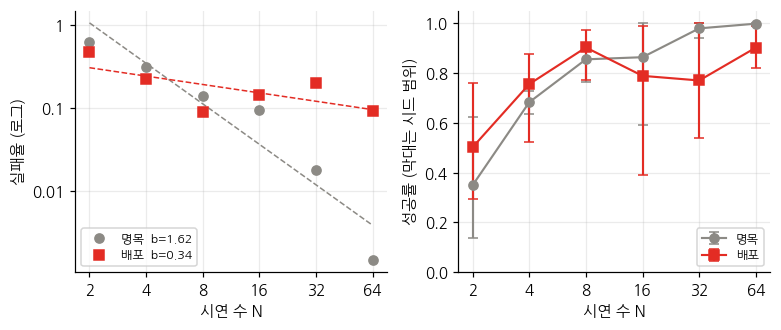

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(7.2, 3.1))
for c, col, mk in (("명목", GREY, "o"), ("배포", RED, "s")):
    fs, b, a, r, r2 = FIT[c]
    ax[0].loglog(NS, fs, mk, color=col, label=f"{c}  b={b:.2f}")
    xx = np.array([NS[0], NS[-1]])
    ax[0].loglog(xx, a * xx ** (-b), "--", color=col, lw=1)
    m = [np.mean(sr(A[(N, c)])) for N in NS]
    lo = [m[i] - min(sr(A[(N, c)])) for i, N in enumerate(NS)]
    hi = [max(sr(A[(N, c)])) - m[i] for i, N in enumerate(NS)]
    ax[1].errorbar(NS, m, yerr=[lo, hi], color=col, marker=mk,
                   capsize=3, lw=1.4, label=c)
# 로그 눈금의 수학 글꼴 음수 기호를 피하려고 평범한 수로 적는다
plain = plt.FuncFormatter(lambda v, _: f"{v:g}")
for a_ in ax:
    a_.set_xscale("log")
    a_.set_xticks(NS)
    a_.set_xticklabels(NS)
    a_.minorticks_off()
ax[0].yaxis.set_major_formatter(plain)
ax[0].set_xlabel("시연 수 N")
ax[0].set_ylabel("실패율 (로그)")
ax[0].legend(fontsize=8, loc="lower left")
ax[1].set_xlabel("시연 수 N")
ax[1].set_ylabel("성공률 (막대는 시드 범위)")
ax[1].set_ylim(0, 1.05)
ax[1].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## 실험 B — 새 배치인가, 되풀이인가

시연을 16판으로 고정하고 **배치 수 K 와 되풀이 M** 의 배분만 바꾼다. 16×1, 8×2, 4×4, 2×8 이다.

그리고 같은 배분을 **잡음 없이** 한 번 더 모은다. 시뮬레이터는 결정론적이므로, 잡음이 없으면 같은 배치의 되풀이는 **같은 궤적의 복사본**이다.

In [13]:
ALLOC = ((16, 1), (8, 2), (4, 4), (2, 8))
B = {}
t0 = time.time()
for sig in (SIG, 0.):
    for K, M in ALLOC:
        rs = []
        for s in SEEDS:
            X, Y = demos(K, M, s, sig)
            m = bc(X, Y, seed=s)
            rows = rollout(mean_act(m), "배포", tag=s,
                           ver=f"k{K}m{M}s{sig:g}", **EV)
            LOG += rows
            rs.append(rate(rows))
        B[(sig, K)] = rs
    dt = time.time() - t0
    print(f"  잡음 {sig:g} 끝  ({dt:.0f}s)", flush=True)

print()
print(pad("배분", 8) + pad(f"잡음 {SIG:g}", 10, True)
      + pad("범위", 15, True) + pad("잡음 0", 10, True)
      + pad("범위", 15, True))
for K, M in ALLOC:
    out = pad(f"{K}×{M}", 8)
    for sig in (SIG, 0.):
        v = B[(sig, K)]
        out += (pad(f"{np.mean(v):.3f}", 10, True)
                + pad(f"[{min(v):.2f}, {max(v):.2f}]", 15, True))
    print(out)

  잡음 0.22 끝  (106s)


  잡음 0 끝  (208s)



배분     잡음 0.22           범위    잡음 0           범위
16×1         0.789   [0.39, 0.99]     0.789   [0.71, 0.84]
8×2          0.860   [0.70, 0.97]     0.700   [0.55, 0.79]
4×4          0.942   [0.91, 0.96]     0.578   [0.47, 0.77]
2×8          0.910   [0.77, 0.99]     0.134   [0.05, 0.20]


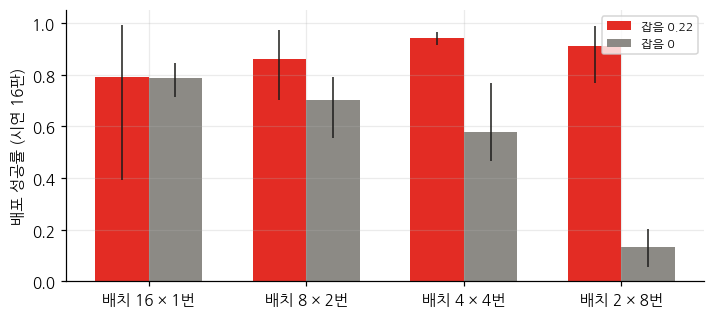

In [14]:
fig, ax = plt.subplots(figsize=(6.6, 3.0))
x = np.arange(len(ALLOC))
w = .34
for i, (sig, col) in enumerate(((SIG, RED), (0., GREY))):
    v = np.array([np.mean(B[(sig, K)]) for K, _ in ALLOC])
    lo = v - np.array([min(B[(sig, K)]) for K, _ in ALLOC])
    hi = np.array([max(B[(sig, K)]) for K, _ in ALLOC]) - v
    ax.bar(x + (i - .5) * w, v, w, yerr=[lo, hi], color=col,
           label=f"잡음 {sig:g}", error_kw=dict(lw=1, ecolor=INK))
ax.set_xticks(x)
ax.set_xticklabels([f"배치 {K} × {M}번" for K, M in ALLOC])
ax.set_ylabel("배포 성공률 (시연 16판)")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

## 시연 수를 정한다

규칙을 코드로 적는다. **명목 평균이 0.95 이상이고 세 시드가 모두 0.90 이상인 가장 작은 N** 을 찾고, 그 두 배를 수집 목표로 삼는다. 두 배는 새 배치에서 드물게 나오는 모서리를 위한 여유다. 배포 성공률은 규칙에 넣지 않는다 — 그 이유가 앞의 표에 있다.

In [15]:
ok = [N for N in NS
      if np.mean(sr(A[(N, "명목")])) >= .95
      and min(sr(A[(N, "명목")])) >= .90]
n_sat = ok[0] if ok else NS[-1]
CFG.update({"demos": int(2 * n_sat), "strata": "kind",
            "rule": "nominal>=.95 & min seed>=.90, x2",
            "scaling": {c: {"b": round(float(FIT[c][1]), 3),
                            "r": round(float(FIT[c][3]), 3),
                            "r2": round(float(FIT[c][4]), 3)}
                        for c in COND}})
os.makedirs("data", exist_ok=True)
with open(CFG_PATH, "w") as f:
    json.dump(CFG, f, ensure_ascii=False, indent=1)
save_log("report/ch03_log.csv", LOG)
if ok:
    print(f"기준을 처음 넘는 N = {n_sat}  →  목표 {2 * n_sat}판")
else:
    print(f"기준을 넘는 N 이 없다 — 최대값 {n_sat} 의 두 배로 둔다")
print()
print("남긴 산출물")
print("  data/collect.json")
print("   ", json.dumps(CFG, ensure_ascii=False))
print(f"  report/ch03_log.csv   판별 로그 {len(LOG):,}줄")

기준을 처음 넘는 N = 32  →  목표 64판

남긴 산출물
  data/collect.json
    {"path": "잡음 주입", "sigma": 0.22, "label": "servo", "steps": 40000, "episodes": 825, "deploy_mean": 0.903, "deploy_range": [0.874, 0.953], "demos": 64, "strata": "kind", "rule": "nominal>=.95 & min seed>=.90, x2", "scaling": {"명목": {"b": 1.621, "r": -0.951, "r2": 0.904}, "배포": {"b": 0.336, "r": -0.692, "r2": 0.479}}}
  report/ch03_log.csv   판별 로그 18,489줄


## 정리

**명목 실패율은 시연 수의 거듭제곱으로 준다.** 지수 1.62, r = −0.951이다. **배포 실패율은 N=8 이후 줄지 않는다.** r = −0.692로 거듭제곱이라 부를 수 없다. 배포에서 남는 실패는 데이터가 아니라 갭의 몫이다.

**다양성과 되풀이의 우열은 잡음 주입 여부에 달렸다.** 잡음이 없으면 배치 수가 전부이고, 잡음이 있으면 배분이 거의 상관없다.

**종류는 층화한다.** 층화하지 않은 수집에서는 적은 N 의 실패가 스케일링이 아니라 표본 추출 사고에서 나온다.

**수집 목표는 64판이다.** 명목 기준을 처음 넘는 N=32의 두 배다. 2장이 모은 825판은 명목 기준으로 열 배 넘게 충분했는데, 배포는 0.903에 머물렀다. 그 틈을 데이터로 메우려 하지 않는다는 것이 1부의 마지막 결정이다.

`data/collect.json` 에 시연 수와 층화 규칙, 두 조건의 적합 결과가 적혔다. 2부가 이 설정과 `data/demos_v1.npz` 를 받아 좌표계와 정규화 통계부터 정한다.